In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
nav = pd.read_csv("../data/processed/02_nav_history_cleaned.csv")

performance = pd.read_csv(
    "../data/processed/07_scheme_performance_cleaned.csv"
)

transactions = pd.read_csv(
    "../data/processed/08_investor_transactions_cleaned.csv"
)

In [3]:
print(nav.shape)
print(performance.shape)
print(transactions.shape)

(46000, 3)
(40, 19)
(32778, 13)


In [5]:
nav["date"] = pd.to_datetime(nav["date"])
nav.head()

,amfi_code,date,nav
0,100016,2022-01-03,520.4608
1,100016,2022-01-04,515.0971
2,100016,2022-01-05,521.7239
3,100016,2022-01-06,515.7880
4,100016,2022-01-07,515.1639


In [6]:
nav = nav.sort_values(["amfi_code", "date"])

nav["daily_return"] = (
    nav.groupby("amfi_code")["nav"]
       .pct_change()
)

In [7]:
nav.head(10)

,amfi_code,date,nav,daily_return
0,100016,2022-01-03,520.4608,NaN
1,100016,2022-01-04,515.0971,-0.010306
2,100016,2022-01-05,521.7239,0.012865
3,100016,2022-01-06,515.7880,-0.011377
4,100016,2022-01-07,515.1639,-0.001210
5,100016,2022-01-10,510.7136,-0.008639
6,100016,2022-01-11,513.5542,0.005562
7,100016,2022-01-12,512.3195,-0.002404
8,100016,2022-01-13,510.2445,-0.004050
9,100016,2022-01-14,514.3636,0.008073


In [8]:
var_results = []

In [9]:
for fund in nav["amfi_code"].unique():

    returns = nav[
        nav["amfi_code"] == fund
    ]["daily_return"].dropna()

    var_95 = np.percentile(returns, 5)

    cvar_95 = returns[
        returns <= var_95
    ].mean()

    var_results.append(
        [fund, var_95, cvar_95]
    )

In [10]:
var_df = pd.DataFrame(
    var_results,
    columns=[
        "amfi_code",
        "VaR_95",
        "CVaR_95"
    ]
)

var_df.head()

,amfi_code,VaR_95,CVaR_95
0,100016,-0.014364,-0.018060
1,100025,-0.003793,-0.004994
2,100033,-0.019034,-0.023456
3,101206,-0.013282,-0.017439
4,101207,-0.026021,-0.032459


In [11]:
var_df = var_df.merge(
    performance[
        ["amfi_code", "scheme_name"]
    ],
    on="amfi_code",
    how="left"
)

In [12]:
var_df.sort_values(
    "VaR_95"
).head()

,amfi_code,VaR_95,CVaR_95,scheme_name
22,119599,-0.026859,-0.032384,SBI Small Cap Fund - Direct Plan - Growth
17,119095,-0.026188,-0.031667,Axis Small Cap Fund - Regular - Growth
4,101207,-0.026021,-0.032459,ABSL Small Cap Fund - Regular - Growth
11,118634,-0.025438,-0.032304,Nippon India Small Cap Fund - Regular - Growth
21,119598,-0.024507,-0.030595,SBI Small Cap Fund - Regular Plan - Growth


In [16]:
var_df.to_csv(
    "../reports/var_cvar_report.csv",
    index=False
)

print("VaR Report Saved")

VaR Report Saved


In [14]:
fund_code = 119551

In [15]:
fund_data = nav[
    nav["amfi_code"] == fund_code
].copy()

fund_data = fund_data.dropna()

In [17]:
fund_data["rolling_sharpe"] = (
    fund_data["daily_return"]
    .rolling(90)
    .mean()
    /
    fund_data["daily_return"]
    .rolling(90)
    .std()
) * np.sqrt(252)

In [18]:
fund_data[
    ["date","rolling_sharpe"]
].tail()

,date,rolling_sharpe
22995,2026-05-25,3.618498
22996,2026-05-26,3.398385
22997,2026-05-27,2.913562
22998,2026-05-28,3.065889
22999,2026-05-29,2.972235


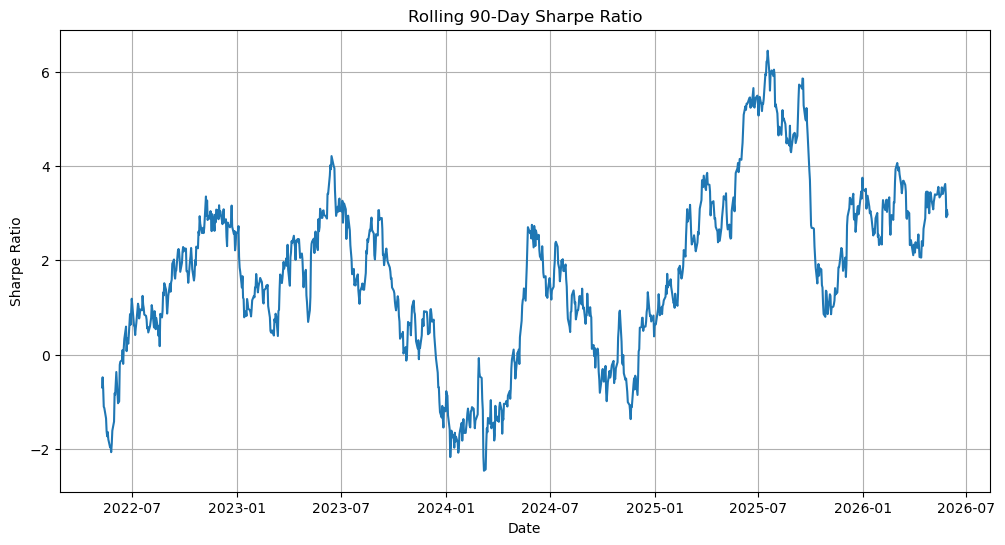

In [19]:
plt.figure(figsize=(12,6))

plt.plot(
    fund_data["date"],
    fund_data["rolling_sharpe"]
)

plt.title(
    "Rolling 90-Day Sharpe Ratio"
)

plt.xlabel("Date")
plt.ylabel("Sharpe Ratio")

plt.grid(True)

plt.show()

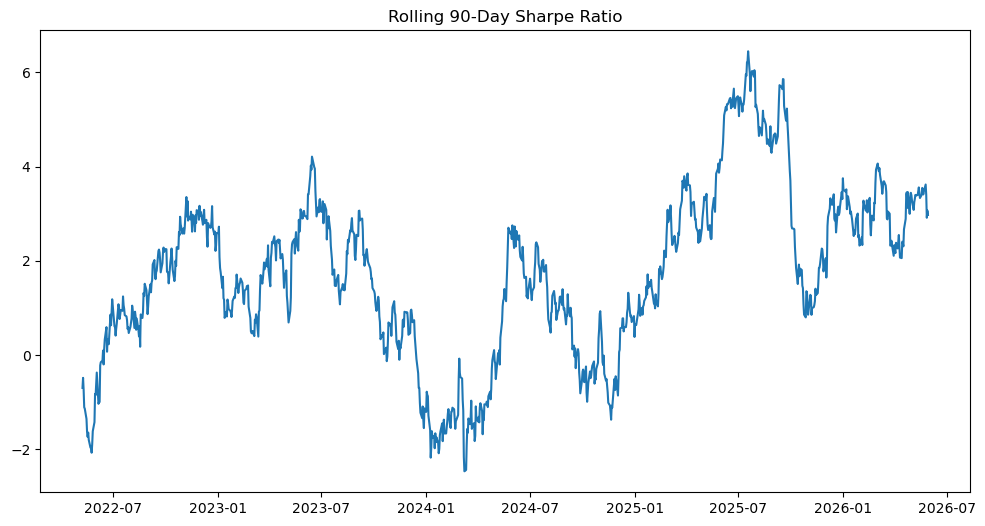

In [20]:
plt.figure(figsize=(12,6))

plt.plot(
    fund_data["date"],
    fund_data["rolling_sharpe"]
)

plt.title(
    "Rolling 90-Day Sharpe Ratio"
)

plt.savefig(
    "../reports/rolling_sharpe_chart.png",
    bbox_inches="tight"
)

plt.show()

In [21]:
import os

os.path.exists(
    "../reports/rolling_sharpe_chart.png"
)

True

In [22]:
transactions["transaction_date"] = pd.to_datetime(
    transactions["transaction_date"]
)

In [23]:
first_txn = (
    transactions
    .groupby("investor_id")
    ["transaction_date"]
    .min()
    .reset_index()
)

first_txn.head()

,investor_id,transaction_date
0,INV000001,2024-11-04
1,INV000002,2024-03-29
2,INV000003,2024-07-16
3,INV000004,2024-03-16
4,INV000005,2024-04-27


In [24]:
first_txn["cohort_year"] = (
    first_txn["transaction_date"]
    .dt.year
)

In [25]:
transactions = transactions.merge(
    first_txn[
        ["investor_id","cohort_year"]
    ],
    on="investor_id",
    how="left"
)

In [26]:
transactions[
    ["investor_id","cohort_year"]
].head()

,investor_id,cohort_year
0,INV003054,2024
1,INV002952,2024
2,INV003420,2024
3,INV003436,2024
4,INV004691,2024


In [27]:
cohort_analysis = (
    transactions
    .groupby("cohort_year")
    .agg(
        investors=("investor_id","nunique"),
        avg_investment=("amount_inr","mean"),
        total_investment=("amount_inr","sum")
    )
    .reset_index()
)

cohort_analysis

,cohort_year,investors,avg_investment,total_investment
0,2024,4803,107422.541832,3491125187
1,2025,197,109158.577061,30455243


In [28]:
cohort_analysis.to_csv(
    "../reports/cohort_analysis.csv",
    index=False
)

print("Cohort Analysis Saved")

Cohort Analysis Saved


In [29]:
sip_txn = transactions[
    transactions["transaction_type"] == "SIP"
].copy()

In [30]:
sip_txn = sip_txn.sort_values(
    ["investor_id","transaction_date"]
)

In [31]:
sip_txn["gap_days"] = (
    sip_txn.groupby("investor_id")
    ["transaction_date"]
    .diff()
    .dt.days
)

In [32]:
sip_txn[
    ["investor_id","transaction_date","gap_days"]
].head(20)

,investor_id,transaction_date,gap_days
19621,INV000001,2024-11-04,NaN
24448,INV000001,2025-01-19,76.0
5650,INV000002,2024-03-29,NaN
16803,INV000002,2024-09-21,176.0
31881,INV000002,2025-05-17,238.0
12652,INV000003,2024-07-16,NaN
27622,INV000003,2025-03-11,238.0
4773,INV000004,2024-03-16,NaN
6418,INV000004,2024-04-11,26.0
8271,INV000004,2024-05-09,28.0


In [33]:
sip_continuity = (
    sip_txn.groupby("investor_id")
    .agg(
        sip_count=("transaction_date","count"),
        avg_gap_days=("gap_days","mean")
    )
    .reset_index()
)

In [34]:
sip_continuity = sip_continuity[
    sip_continuity["sip_count"] >= 6
]

In [35]:
sip_continuity["status"] = np.where(
    sip_continuity["avg_gap_days"] > 35,
    "At Risk",
    "Active"
)

In [36]:
sip_continuity.head()

,investor_id,sip_count,avg_gap_days,status
3,INV000004,6,85.400000,At Risk
7,INV000008,6,70.400000,At Risk
9,INV000010,6,64.800000,At Risk
10,INV000011,7,40.166667,At Risk
11,INV000012,8,57.000000,At Risk


In [37]:
sip_continuity["status"].value_counts()

status
At Risk    1332
Active       30
Name: count, dtype: int64

In [38]:
sip_continuity.to_csv(
    "../reports/sip_continuity.csv",
    index=False
)

print("SIP Continuity Saved")

SIP Continuity Saved


In [39]:
recommendation = performance.copy()

recommendation["score"] = (
    recommendation["return_3yr_pct"] * 0.5
    +
    recommendation["sharpe_ratio"] * 30
    -
    recommendation["expense_ratio_pct"] * 10
)

In [40]:
recommendation = recommendation.sort_values(
    "score",
    ascending=False
)

In [41]:
recommendation[
    [
        "scheme_name",
        "return_3yr_pct",
        "sharpe_ratio",
        "expense_ratio_pct",
        "score"
    ]
].head(10)

,scheme_name,return_3yr_pct,sharpe_ratio,expense_ratio_pct,score
14,ICICI Pru Liquid Fund - Regular - Growth,7.68,7.68,0.74,226.840
23,Kotak Liquid Fund - Regular - Growth,6.18,6.18,0.60,182.490
30,ABSL Liquid Fund - Regular - Growth,5.14,5.14,0.79,148.870
9,HDFC Short Term Debt Fund - Regular - Growth,7.37,1.84,0.56,53.285
4,SBI Magnum Gilt Fund - Regular Plan - Growth,6.07,1.52,0.77,40.935
19,Nippon India Gilt Securities Fund - Regular - ...,5.31,1.33,0.55,37.055
3,SBI Small Cap Fund - Direct Plan - Growth,23.14,0.93,0.72,32.270
11,ICICI Pru Bluechip Fund - Direct - Growth,14.41,1.03,0.80,30.105
6,HDFC Top 100 Fund - Direct Plan - Growth,13.38,0.96,0.92,26.290
2,SBI Small Cap Fund - Regular Plan - Growth,23.39,0.94,1.43,25.595


In [42]:
recommendation.to_csv(
    "../reports/fund_recommendations.csv",
    index=False
)

print("Fund Recommendations Saved")

Fund Recommendations Saved


In [43]:
risk_segmentation = performance.copy()

risk_segmentation["risk_segment"] = pd.cut(
    risk_segmentation["std_dev_ann_pct"],
    bins=[0, 10, 20, 100],
    labels=[
        "Low Risk",
        "Medium Risk",
        "High Risk"
    ]
)

In [44]:
risk_segmentation["risk_segment"].value_counts()

risk_segment
Medium Risk    28
Low Risk        6
High Risk       6
Name: count, dtype: int64

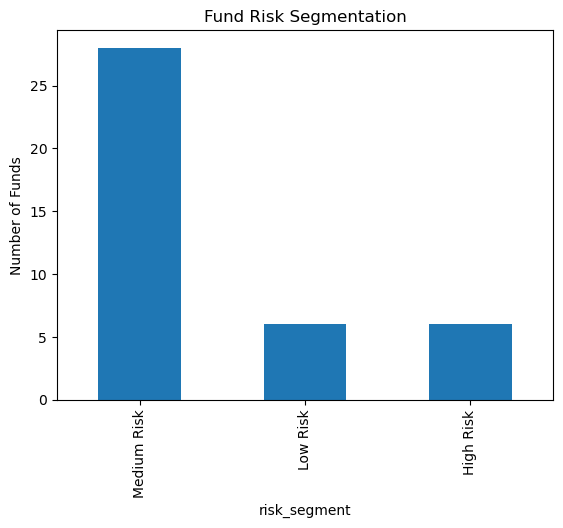

In [45]:
risk_segmentation["risk_segment"].value_counts().plot(
    kind="bar"
)

plt.title(
    "Fund Risk Segmentation"
)

plt.ylabel("Number of Funds")

plt.show()

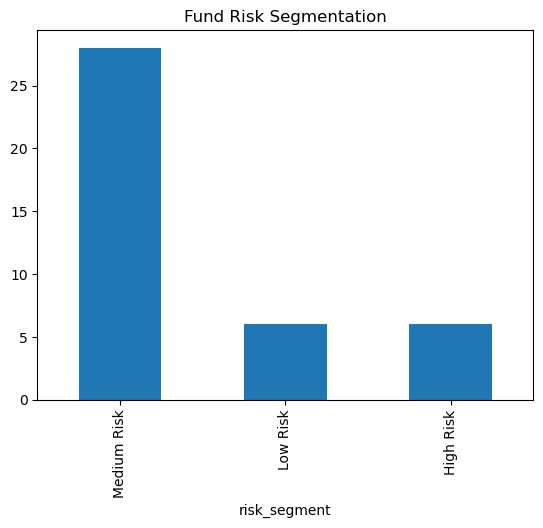

In [46]:
risk_segmentation["risk_segment"].value_counts().plot(
    kind="bar"
)

plt.title(
    "Fund Risk Segmentation"
)

plt.savefig(
    "../reports/risk_segmentation.png",
    bbox_inches="tight"
)

plt.show()

In [47]:
risk_segmentation.to_csv(
    "../reports/risk_segmentation.csv",
    index=False
)

print("Risk Segmentation Saved")

Risk Segmentation Saved
